Step-1: Import Required Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step-2: Load Dataset

In [48]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step-3: Check Dataset Information

In [49]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Step-4: Clean Missing Data

1.Fill missing Age values using average age:

In [50]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

2.Fill missing Embarked values:

In [51]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

3.Drop Cabin column because it has many missing values:

In [52]:
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
else:
    print("Column 'Cabin' not found in DataFrame, it might have been dropped already.")

4.check null values

In [53]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Step-5: Survival Count

Male vs Female Survival

In [54]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


Step-6:Passenger Class Survival

In [55]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Step-7: Create Age Groups

In [56]:
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

Step-8:Check survival by age group

In [58]:
df.groupby('AgeGroup')['Survived'].mean()

/tmp/ipykernel_16611/2140893742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.410526
Young Adult,0.352941
Adult,0.400000
Senior,0.227273


Step-9: Visualization – Survival by Gender

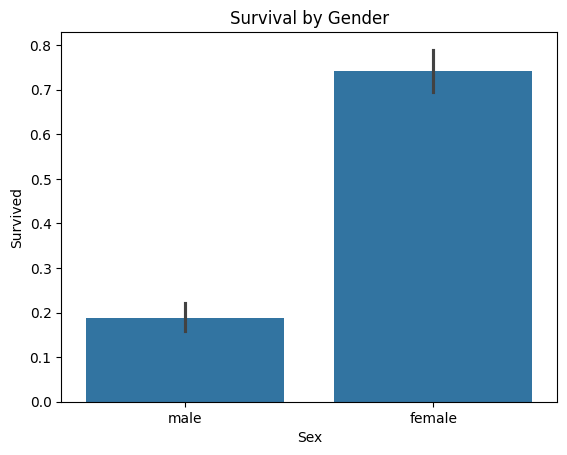

In [60]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

Step-10: Visualization – Survival by Passenger Class

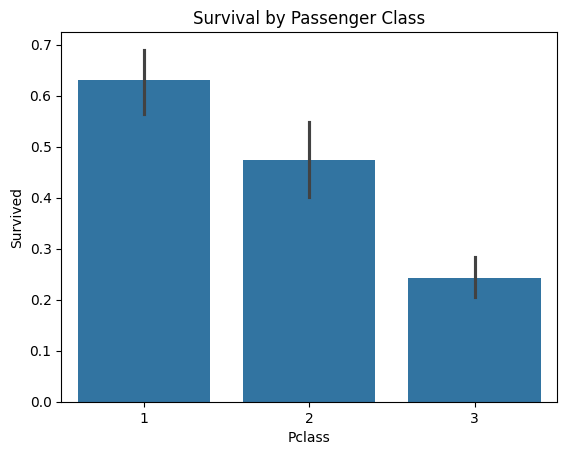

In [61]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

Step-11: Visualization – Age Distribution

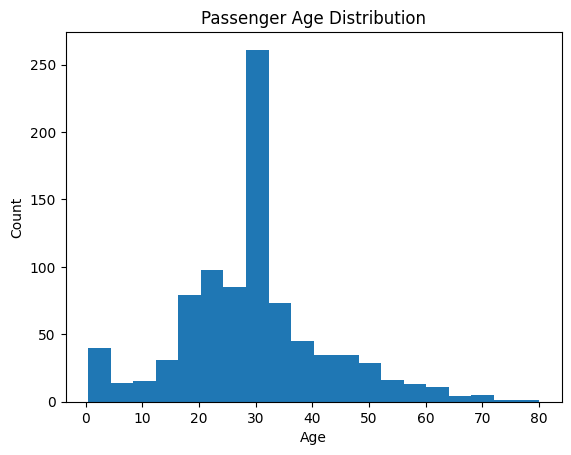

In [62]:
plt.hist(df['Age'], bins=20)
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Conclusion:

1. Females survived more than males.
2. First-class passengers had higher survival rates.
3. Young adults were the largest passenger group.
4. Data visualization helped identify survival patterns clearly.